***Drive'ı Bağlama ve Veriyi Okuma***

In [1]:
from google.colab import drive
import pandas as pd

# 1. Drive'ı bağla
drive.mount('/content/drive')

# 2. Dosya yolunu belirle
dosya_yolu = "/content/drive/MyDrive/Istanbul_Emlak_Projesi/istanbul_apartment_prices_2026.csv"

# 3. Veriyi oku
df = pd.read_csv(dosya_yolu)

# 4. Verinin ilk 5 satırına bakarak her şeyin yolunda olduğunu teyit et
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04


In [2]:
# Her sütundaki toplam eksik (NaN) değer sayısını göster
print(df.isnull().sum())

listing_id                0
price                     0
price_per_sqm             0
district                  0
neighborhood              0
rooms                     0
halls                     0
total_rooms               0
gross_sqm                 0
net_sqm                   0
floor                  1917
floor_category        17372
total_floors              1
building_age              0
building_type         14561
building_condition    13847
heating_type              0
fuel_type             13853
bathroom_count          235
furnished              1078
usage_status            634
is_in_complex             0
complex_name          21014
orientation            5316
maintenance_fee       15765
credit_eligible           7
deed_status               1
exchange               1597
last_updated          11893
scraped_at                0
dtype: int64


***"Feature Engineering" (Özellik Mühendisliği)***

Ağır yaralı sütunları hayata döndürme

In [3]:
# 1. VERİYİ EN BAŞTAN TERTEMİZ OKU
dosya_yolu = "/content/drive/MyDrive/Istanbul_Emlak_Projesi/istanbul_apartment_prices_2026.csv"
df = pd.read_csv(dosya_yolu)

# 2. KATİLLERİ YOK ET
df = df.drop(columns=['last_updated', 'exchange', 'floor'])

# 3. feature engineering
df['furnished'] = df['furnished'].fillna('Eşyasız')
df['floor_category'] = df['floor_category'].fillna('Daire')
df['complex_name'] = df['complex_name'].fillna('Normal Apartman')

def yas_kategorisi_belirle(yas):
    if yas <= 2:
        return 'Sıfır'
    elif yas <= 10:
        return 'Yeni'
    elif yas <= 20:
        return 'Genç'
    elif yas <= 40:
        return 'Eski'
    else:
        return 'Çok Eski'

bos_durum_indeksleri = df['building_condition'].isnull()
df.loc[bos_durum_indeksleri, 'building_condition'] = df.loc[bos_durum_indeksleri, 'building_age'].apply(yas_kategorisi_belirle)

kategorik_kolonlar = ['fuel_type', 'building_type', 'orientation', 'usage_status']
for kolon in kategorik_kolonlar:
    en_cok_tekrar_eden = df[kolon].mode()[0]
    df[kolon] = df[kolon].fillna(en_cok_tekrar_eden)

df['maintenance_fee'] = df['maintenance_fee'].fillna(0)
df['bathroom_count'] = df['bathroom_count'].fillna(1)

# 4. SON PÜRÜZLERİ SİL
df = df.dropna()

print("🌟 Gerçek Temizlik ŞİMDİ Tamamlandı! Kalan İlan Sayısı:", df.shape[0])

🌟 Gerçek Temizlik ŞİMDİ Tamamlandı! Kalan İlan Sayısı: 24758


***Lokasyon Zekası'na (Geospatial Analysis)***

In [4]:
import folium

# 1. Veriyi İlçelere Göre Grupla (Metrekare fiyatlarını ve ortalama fiyatları bulalım)
ilce_analizi = df.groupby('district').agg(
    ortalama_fiyat=('price', 'mean'),
    ortalama_m2_fiyati=('price_per_sqm', 'mean'),
    ilan_sayisi=('price', 'count') # Kaç tane ilan var?
).reset_index()

# En pahalı 5 ilçeyi (Metrekare fiyatına göre) ucuza doğru sırala
en_pahali_ilceler = ilce_analizi.sort_values('ortalama_m2_fiyati', ascending=False)
print("🏆 İstanbul'un En Pahalı 5 İlçesi (m² bazında):")
print(en_pahali_ilceler.head())

# 2. Temel İstanbul Haritasını Oluştur
istanbul_merkez_koordinat = [41.0082, 28.9784]
m = folium.Map(location=istanbul_merkez_koordinat, zoom_start=10, tiles='cartodbpositron')

# Haritayı ekrana bas (Sadece m yazmak Colab'de haritayı gösterir)
m

🏆 İstanbul'un En Pahalı 5 İlçesi (m² bazında):
      district  ortalama_fiyat  ortalama_m2_fiyati  ilan_sayisi
5     Bakırköy    4.243546e+07       777143.216944          674
6   Bayrampaşa    6.794177e+07       384424.674286          189
12    Beşiktaş    3.559472e+07       253962.656917          905
22   Kağıthane    1.998283e+07       245319.848808         1057
19    Güngören    2.826374e+07       244530.286051          195


In [5]:
# 1. İlçe ve Mahalle bazında grupla, uçuk hatalara karşı 'median' kullan!
mahalle_analizi = df.groupby(['district', 'neighborhood']).agg(
    medyan_m2_fiyati=('price_per_sqm', 'median'),
    ilan_sayisi=('price', 'count')
).reset_index()

# 2. Sadece en az 10 ilanı olan mahalleleri al (Tek 1 troll ilan listeyi bozmasın)
guvenilir_mahalleler = mahalle_analizi[mahalle_analizi['ilan_sayisi'] > 10]

# 3. Gerçek kralları sırala!
gercek_liste = guvenilir_mahalleler.sort_values('medyan_m2_fiyati', ascending=False)
print("🏆 İŞTE İSTANBUL'UN GERÇEK EN PAHALI 10 MAHALLESİ (M² Bazında):")
print(gercek_liste.head(10).to_string(index=False))

🏆 İŞTE İSTANBUL'UN GERÇEK EN PAHALI 10 MAHALLESİ (M² Bazında):
   district neighborhood  medyan_m2_fiyati  ilan_sayisi
   Beşiktaş         Akat        406212.120           66
   Beşiktaş    Kuruçeşme        369924.810           14
   Beşiktaş       Etiler        367125.045          106
   Beşiktaş        Bebek        347222.220           41
Zeytinburnu   Kazlıçeşme        345454.550           31
    Kadıköy   Fenerbahçe        324122.810           70
    Sarıyer      İstinye        319444.440           22
      Şişli      Harbiye        306250.000           29
    Sarıyer      Poligon        298125.000           24
    Kadıköy  Caddebostan        280384.615          114


In [10]:
print(df[df['district'] == 'Şile'])

Empty DataFrame
Columns: [listing_id, price, price_per_sqm, district, neighborhood, rooms, halls, total_rooms, gross_sqm, net_sqm, floor_category, total_floors, building_age, building_type, building_condition, heating_type, fuel_type, bathroom_count, furnished, usage_status, is_in_complex, complex_name, orientation, maintenance_fee, credit_eligible, deed_status, scraped_at]
Index: []

[0 rows x 27 columns]


***Keşifçi Veri Analizi (EDA - Exploratory Data Analysis)***

🏢 KONUT TİPLERİ DAĞILIMI:
building_type
Reinforced Concrete    24614
Masonry                   76
Steel                     26
Wooden                    16
Brick                     15
Stone                     10
Log                        1
Name: count, dtype: int64
----------------------------------------
🔍 EN AZ İLANA SAHİP 5 İLÇE:
district
Güngören      195
Bayrampaşa    189
Beyoğlu       186
Beykoz        100
Çatalca         7
Name: count, dtype: int64
----------------------------------------


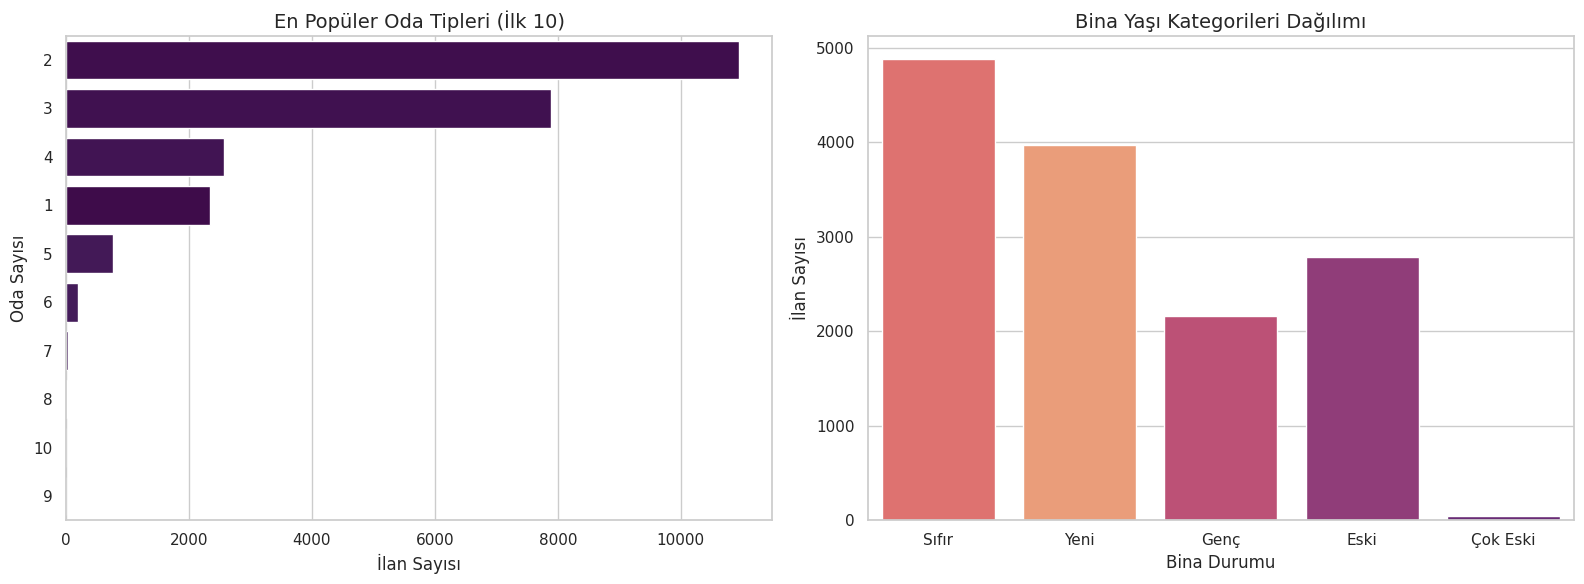

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafikler için Türkçe karakter uyumu ve stil ayarı
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# 1. Konut Tipleri: Sadece daire mi var, araya villa falan sızmış mı?
print("🏢 KONUT TİPLERİ DAĞILIMI:")
print(df['building_type'].value_counts())
print("-" * 40)

# 2. Şile Gizemi: En az ilanı olan 5 ilçe hangisi?
print("🔍 EN AZ İLANA SAHİP 5 İLÇE:")
print(df['district'].value_counts().tail(5))
print("-" * 40)

# 3. Görselleştirme: İstanbul'un Emlak Profili (Oda Sayısı ve Bina Yaşı)
plt.figure(figsize=(16, 6))

# Sol Grafik: Oda Sayıları
plt.subplot(1, 2, 1)
# Sadece en çok tekrar eden ilk 10 oda tipini alalım ki grafik çorba olmasın
top_rooms = df['rooms'].value_counts().index[:10]
sns.countplot(y=df['rooms'], order=top_rooms, hue=df['rooms'], legend=False, palette='viridis')
plt.title('En Popüler Oda Tipleri (İlk 10)', fontsize=14)
plt.xlabel('İlan Sayısı')
plt.ylabel('Oda Sayısı')

# Sağ Grafik: Senin Yarattığın Bina Yaşı Kategorileri!
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='building_condition', order=['Sıfır', 'Yeni', 'Genç', 'Eski', 'Çok Eski'], hue='building_condition', legend=False, palette='magma')
plt.title('Bina Yaşı Kategorileri Dağılımı', fontsize=14)
plt.xlabel('Bina Durumu')
plt.ylabel('İlan Sayısı')

plt.tight_layout()
plt.show()

**3D Pydeck dünyasına giriş yapıyoruz**

In [11]:
# Önce Colab'e pydeck'i tekrar indirelim
!pip install pydeck

import pydeck as pdk
import pandas as pd
import numpy as np

# Az önceki "df_harita is not defined" hatasını da burada kökten çözüyoruz:
# Ana temiz tablomuzu (df), harita işlemleri için kopyalıyoruz
df_harita = df.copy()

# 1. VERİYİ GARANTİYE ALALIM
df_final_map = df_harita.groupby('district')['price_per_sqm'].median().reset_index()
# ...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.8 MB/s eta 0:00:00


In [13]:
!pip install pydeck

import pydeck as pdk
import pandas as pd
import numpy as np

# 0. KAYBOLAN KOORDİNAT SÖZLÜĞÜNÜ GERİ GETİRİYORUZ
ilce_koordinatlari = {
    'Adalar': [40.8700, 29.1200], 'Arnavutköy': [41.1819, 28.7402], 'Ataşehir': [40.9926, 29.1228],
    'Avcılar': [40.9901, 28.7118], 'Bağcılar': [41.0344, 28.8336], 'Bahçelievler': [40.9991, 28.8633],
    'Bakırköy': [40.9786, 28.8722], 'Başakşehir': [41.0963, 28.7885], 'Bayrampaşa': [41.0471, 28.8967],
    'Beşiktaş': [41.0428, 29.0076], 'Beykoz': [41.1179, 29.0955], 'Beylikdüzü': [40.9904, 28.6493],
    'Beyoğlu': [41.0369, 28.9776], 'Büyükçekmece': [41.0216, 28.5901], 'Çatalca': [41.1428, 28.4608],
    'Çekmeköy': [41.0407, 29.1724], 'Esenler': [41.0363, 28.8872], 'Esenyurt': [41.0343, 28.6811],
    'Eyüpsultan': [41.0435, 28.9340], 'Fatih': [41.0092, 28.9413], 'Gaziosmanpaşa': [41.0566, 28.9130],
    'Güngören': [41.0253, 28.8723], 'Kadıköy': [40.9910, 29.0270], 'Kağıthane': [41.0809, 28.9734],
    'Kartal': [40.8994, 29.1917], 'Küçükçekmece': [41.0006, 28.7806], 'Maltepe': [40.9416, 29.1417],
    'Pendik': [40.8767, 29.2319], 'Sancaktepe': [41.0002, 29.2310], 'Sarıyer': [41.1661, 29.0494],
    'Silivri': [41.0742, 28.2481], 'Sultanbeyli': [40.9663, 29.2678], 'Sultangazi': [41.1044, 28.8617],
    'Şile': [41.1764, 29.6101], 'Şişli': [41.0600, 28.9870], 'Tuzla': [40.8163, 29.3039],
    'Ümraniye': [41.0232, 29.1023], 'Üsküdar': [41.0274, 29.0175], 'Zeytinburnu': [40.9881, 28.8950]
}

# Veri tablomuzu harita için hazırla
df_harita = df.copy()

# 1. VERİYİ GARANTİYE ALALIM
df_final_map = df_harita.groupby('district')['price_per_sqm'].median().reset_index()
df_final_map.columns = ['ilce', 'fiyat']

# Koordinatları ekleyelim
coords = pd.DataFrame.from_dict(ilce_koordinatlari, orient='index', columns=['lat', 'lng']).reset_index()
coords.columns = ['ilce', 'lat', 'lng']
df_final_map = pd.merge(df_final_map, coords, on='ilce')

# 2. RENK VE ESTETİK YÜKSEKLİK AYARI
q1 = df_final_map['fiyat'].quantile(0.33)
q2 = df_final_map['fiyat'].quantile(0.66)

def get_color(f):
    if f <= q1: return [46, 204, 113, 200]   # YEŞİL
    if f <= q2: return [241, 196, 15, 200]   # SARI
    return [231, 76, 60, 200]                # KIRMIZI

df_final_map['renk'] = df_final_map['fiyat'].apply(get_color)

# Gökdelen Etkisi
df_final_map['yukseklik'] = df_final_map['fiyat'] / 100

# 3. 3D ŞEHİR TASARIMI
view_state = pdk.ViewState(latitude=41.0082, longitude=28.9784, zoom=10, pitch=60)

layer = pdk.Layer(
    "ColumnLayer",
    df_final_map,
    get_position=["lng", "lat"],
    get_elevation="yukseklik",
    elevation_scale=1,
    radius=400,
    get_fill_color="renk",
    pickable=True,
    auto_highlight=True,
)

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style=pdk.map_styles.CARTO_DARK,
    tooltip={
        "html": "<b>İlçe:</b> {ilce}<br/><b>m² Fiyatı:</b> {fiyat} TL",
        "style": {"color": "white", "backgroundColor": "#2c3e50"}
    }
)

# Haritayı ekrana bas
r.to_html("istanbul_3d_final.html", notebook_display=True)

<IPython.core.display.Javascript object>

***"İlanın Konumunu Göster" Özelliği (Folium ile Mini Harita)***

In [14]:
import folium
import numpy as np

# 1. Örnek Bir İlan Seçelim (Kadıköy Moda olsun)
ornek_ilan = df[(df['district'] == 'Kadıköy') & (df['neighborhood'] == 'Caferağa')].iloc[0]

# Kadıköy Caferağa'nın tahmini merkez koordinatları
merkez_lat, merkez_lon = 40.9825, 29.0255

# Üst üste binmemesi için çok küçük bir "gürültü" (noise) ekliyoruz
sapma_lat = np.random.normal(0, 0.002)
sapma_lon = np.random.normal(0, 0.002)
ilan_lat = merkez_lat + sapma_lat
ilan_lon = merkez_lon + sapma_lon

# 2. Mini Haritayı Oluştur
ilan_haritasi = folium.Map(location=[ilan_lat, ilan_lon], zoom_start=15, tiles='cartodbpositron')

# 3. İlan İşaretçisini (Marker) Ekle
popup_metni = f"""
<b>📍 Evin Konumu</b><br>
<b>İlçe:</b> {ornek_ilan['district']}<br>
<b>Mahalle:</b> {ornek_ilan['neighborhood']}<br>
<b>Fiyat:</b> {ornek_ilan['price']:,.0f} TL<br>
<b>Oda:</b> {ornek_ilan['rooms']} + {ornek_ilan['halls']}
"""

folium.Marker(
    location=[ilan_lat, ilan_lon],
    popup=popup_metni,
    icon=folium.Icon(color="red", icon="home")
).add_to(ilan_haritasi)

print("📌 Seçilen İlanın Haritadaki Konumu:")
# Sadece haritanın adını yazarak ekranda gösteriyoruz
ilan_haritasi

📌 Seçilen İlanın Haritadaki Konumu:


***Bölgeye Göre İlan Listeleme Özelliği (İnteraktif Filtreleme)***

In [15]:
import ipywidgets as widgets
from IPython.display import display

# Tüm ilçelerin listesini al
ilce_listesi = sorted(df['district'].unique().tolist())

# Bir Dropdown (Açılır Menü) oluştur
ilce_secici = widgets.Dropdown(
    options=ilce_listesi,
    value='Beşiktaş', # Varsayılan olarak Beşiktaş seçili gelsin
    description='🎯 İlçe Seç:',
    disabled=False,
)

# Filtreleme yapacak ve sonuçları basacak fonksiyon
def ilceye_gore_analiz_yap(secilen_ilce):
    print(f"\n{'='*50}")
    print(f"📊 {secilen_ilce.upper()} İLÇESİ ANALİZ RAPORU")
    print(f"{'='*50}\n")

    # 1. Sadece seçilen ilçenin verisini filtrele
    df_ilce = df[df['district'] == secilen_ilce]

    # 2. Temel İstatistikleri Hesapla
    toplam_ilan = len(df_ilce)
    ortalama_fiyat = df_ilce['price'].mean()
    ortalama_m2 = df_ilce['price_per_sqm'].mean()

    print(f"📌 Toplam İlan Sayısı: {toplam_ilan}")
    print(f"💰 Ortalama Ev Fiyatı: {ortalama_fiyat:,.0f} TL")
    print(f"📏 Ortalama m² Fiyatı: {ortalama_m2:,.0f} TL\n")

    # 3. O İlçedeki En Pahalı 5 Evi Listele
    print(f"🔥 {secilen_ilce} İlçesindeki En Pahalı 5 İlan:")
    en_pahali_5 = df_ilce[['neighborhood', 'rooms', 'net_sqm', 'price', 'building_age']].sort_values('price', ascending=False).head(5)
    display(en_pahali_5) # Dataframe'i şık bir tablo olarak göster

# Dropdown ile fonksiyonu birbirine bağla
# Sen menüden ilçe değiştirdikçe bu fonksiyon otomatik çalışacak
gosterge_paneli = widgets.interactive(ilceye_gore_analiz_yap, secilen_ilce=ilce_secici)

# Ekrana bas
display(gosterge_paneli)

interactive(children=(Dropdown(description='🎯 İlçe Seç:', index=12, options=('Adalar', 'Arnavutköy', 'Ataşehir…

***Her İlan İçin Dinamik Harita Gösterme***

In [16]:
!pip install geopy

import pandas as pd
from geopy.geocoders import Nominatim
import time

print("Adım 1: Benzersiz lokasyonlar listeleniyor...")
# Sadece benzersiz İlçe-Mahalle eşleşmelerini alıyoruz ki işlem saniyeler sürsün, saatler değil
lokasyon_df = df[['district', 'neighborhood']].drop_duplicates().reset_index(drop=True)

# Harita servisinin anlayacağı formata çeviriyoruz: "Caferağa, Kadıköy, İstanbul"
lokasyon_df['adres_sorgusu'] = lokasyon_df['neighborhood'] + ", " + lokasyon_df['district'] + ", İstanbul"

# Ücretsiz OpenStreetMap servisini (Nominatim) başlatıyoruz
geolocator = Nominatim(user_agent="selen_emlak_projesi_2026")

def koordinat_bul(adres):
    try:
        # Harita servisini çökertmemek için her sorguda 1 saniye nefes alıyoruz
        time.sleep(1)
        location = geolocator.geocode(adres, timeout=10)
        if location:
            return pd.Series([location.latitude, location.longitude])
        else:
            return pd.Series([None, None]) # Bulamazsa boş bırak
    except:
        return pd.Series([None, None])

print("Adım 2: İnternetten koordinatlar çekiliyor (Bu işlem mahalle sayısına göre 1-2 dakika sürebilir)...")
# Fonksiyonu çalıştır ve lat/lon kolonlarını doldur
lokasyon_df[['lat', 'lon']] = lokasyon_df['adres_sorgusu'].apply(koordinat_bul)

print("Adım 3: Koordinatlar ana tabloya (df) entegre ediliyor...")
# Bulduğumuz altın değerindeki koordinatları ana tablomuzla birleştiriyoruz
df_koordinatli = pd.merge(df, lokasyon_df[['district', 'neighborhood', 'lat', 'lon']], on=['district', 'neighborhood'], how='left')

print("✅ İŞLEM TAMAM! İşte yeni verin:")
display(df_koordinatli[['district', 'neighborhood', 'price', 'lat', 'lon']].head(10))

Adım 1: Benzersiz lokasyonlar listeleniyor...
Adım 2: İnternetten koordinatlar çekiliyor (Bu işlem mahalle sayısına göre 1-2 dakika sürebilir)...
Adım 3: Koordinatlar ana tabloya (df) entegre ediliyor...
✅ İŞLEM TAMAM! İşte yeni verin:


,district,neighborhood,price,lat,lon
0,Adalar,Maden,15900000,40.873905,29.130988
1,Adalar,Nizam,40000000,40.873726,29.128458
2,Adalar,Nizam,17850000,40.873726,29.128458
3,Adalar,Heybeliada,16000000,40.876260,29.091033
4,Adalar,Nizam,14000000,40.873726,29.128458
5,Adalar,Heybeliada,12000000,40.876260,29.091033
6,Adalar,Maden,21900000,40.873905,29.130988
7,Adalar,Maden,6500000,40.873905,29.130988
8,Adalar,Kınalıada,18500000,40.908891,29.054798
9,Adalar,Maden,12100000,40.873905,29.130988


In [17]:
display(df_koordinatli.tail(10))

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,scraped_at,lat,lon
24748,123120-141,3750000,42134.83,Zeytinburnu,Beştelsiz,2,1,3,90.0,89.0,...,Vacant,0,Normal Apartman,South,0.0,Eligible,Construction Easement,2026-03-19T04:48:15,40.999487,28.904502
24749,109079-973,7600000,63333.33,Zeytinburnu,Beştelsiz,2,1,3,130.0,120.0,...,Vacant,0,Normal Apartman,South,100.0,Eligible,No Title Deed,2026-03-19T04:48:24,40.999487,28.904502
24750,3448-15267,16750000,328431.37,Zeytinburnu,Kazlıçeşme,1,1,2,83.0,51.0,...,Tenant-occupied,1,Büyükyalı İstanbul,South,0.0,Eligible,Condominium Title,2026-03-19T04:48:35,40.992673,28.916890
24751,123120-112,5500000,61111.11,Zeytinburnu,Çırpıcı,2,1,3,95.0,90.0,...,Vacant,0,Normal Apartman,South,0.0,Not Eligible,Condominium Title,2026-03-19T04:48:43,41.000225,28.896244
24752,123120-111,6000000,85714.29,Zeytinburnu,Çırpıcı,2,1,3,75.0,70.0,...,Vacant,0,Normal Apartman,South,0.0,Not Eligible,Condominium Title,2026-03-19T04:48:52,41.000225,28.896244
24753,3448-15270,23500000,183593.75,Zeytinburnu,Seyitnizam,3,1,4,185.0,128.0,...,Vacant,0,Normal Apartman,South,0.0,Eligible,No Title Deed,2026-03-19T04:49:03,41.006495,28.908933
24754,3448-15034,42500000,293103.45,Zeytinburnu,Kazlıçeşme,3,1,4,195.0,145.0,...,Tenant-occupied,1,Büyükyalı İstanbul,South,0.0,Eligible,Condominium Title,2026-03-19T04:49:14,40.992673,28.916890
24755,144355-735,7000000,194444.44,Zeytinburnu,Veliefendi,1,1,2,52.0,36.0,...,Vacant,1,Mega Garden Park,"South, East",0.0,Eligible,Construction Easement,2026-03-19T04:49:25,40.995942,28.897893
24756,144355-444,12000000,179104.48,Zeytinburnu,Veliefendi,2,1,3,97.0,67.0,...,Vacant,1,Mega Garden Park,South,0.0,Eligible,Construction Easement,2026-03-19T04:49:39,40.995942,28.897893
24757,3448-15172,3350000,33500.00,Zeytinburnu,Sümer,3,1,4,120.0,100.0,...,Vacant,0,Normal Apartman,South,0.0,Eligible,Construction Easement,2026-03-19T04:49:55,40.986405,28.895472
